# Cập nhật package list và cài build tools


In [1]:
!sudo apt-get update -q
!sudo apt-get install -y -q build-essential wget git
!g++ --version

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,307 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,228 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [4,028 kB

# Tạo thư mục gốc cho toàn bộ experiment


In [2]:
!mkdir -p /kaggle/working/experiments
%cd /kaggle/working/experiments

/kaggle/working/experiments


# THƯ VIỆN & CẤU HÌNH


In [3]:
!pip install -q openml scikit-learn pandas numpy

import os
import time
import subprocess
import re
import warnings
import numpy as np
import pandas as pd
import openml
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MaxAbsScaler
from sklearn.datasets import dump_svmlight_file, load_svmlight_file

EXPERIMENTS_DIR = '/kaggle/working/experiments'
DATA_DIR = os.path.join(EXPERIMENTS_DIR, 'data')
os.makedirs(DATA_DIR, exist_ok=True)
RANDOM_STATE = 42
openml.config.apikey = ''

EXPERIMENT_CONFIG = {
    # 'census_housing':    {'task': 'regression',     'n_features': 121, 'expected_N': 22732,  'pcts': [10, 30, 50, 90]},
    # 'computer_activity': {'task': 'regression',     'n_features': 21,  'expected_N': 8192,   'pcts': [10, 30, 50, 90]},
    # 'elevators':         {'task': 'regression',     'n_features': 18,  'expected_N': 16599,  'pcts': [10, 30, 50, 90]},
    # 'friedman':          {'task': 'regression',     'n_features': 10,  'expected_N': 100000, 'pcts': [5, 10, 20, 35, 50, 70, 90]},
    'friedman':          {'task': 'regression',     'n_features': 10,  'expected_N': 100000, 'pcts': [5, 10, 20, 35, 50]},
    # 'pole_telecomm':     {'task': 'regression',     'n_features': 48,  'expected_N': 15000,  'pcts': [10, 30, 50, 90]},
    # 'superconduct':      {'task': 'regression',     'n_features': 81,  'expected_N': 21263,  'pcts': [10, 30, 50, 90]},
    # 'bike_sharing':      {'task': 'regression',     'n_features': 12,  'expected_N': 17379,  'pcts': [10, 30, 50, 90]},
    # 'covertype':         {'task': 'classification', 'n_features': 54,  'expected_N': 581012, 'pcts': [1, 2, 5, 10, 20, 30, 50, 70, 90]},
}

TMP_DIR = os.path.join(EXPERIMENTS_DIR, 'tmp')
os.makedirs(TMP_DIR, exist_ok=True)

CVR_TRAIN_BIN  = os.path.join(EXPERIMENTS_DIR, 'cvr_train')

LIBSVM_DIR     = os.path.join(EXPERIMENTS_DIR, 'libsvm')
LIBSVM_TRAIN   = os.path.join(LIBSVM_DIR, 'svm-train')
LIBSVM_PREDICT = os.path.join(LIBSVM_DIR, 'svm-predict')

SVMLIGHT_DIR   = os.path.join(EXPERIMENTS_DIR, 'svm_light')
SVMLIGHT_LEARN = os.path.join(SVMLIGHT_DIR, 'svm_learn')
SVMLIGHT_CLASS = os.path.join(SVMLIGHT_DIR, 'svm_classify')

LIBCVM_DIR  = os.path.join(EXPERIMENTS_DIR, 'libCVM')
CVM_TRAIN   = os.path.join(LIBCVM_DIR, 'svm-train')
CVM_PREDICT = os.path.join(LIBCVM_DIR, 'svm-predict')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 5.2 MB/s eta 0:00:00


# BIÊN DỊCH LIBSVM

In [4]:
!git clone --depth 1 https://github.com/cjlin1/libsvm.git
%cd libsvm
!make clean && make
%cd /kaggle/working/experiments

!test -f libsvm/svm-train   && echo "[OK] svm-train"   || echo "[FAIL] svm-train"
!test -f libsvm/svm-predict && echo "[OK] svm-predict" || echo "[FAIL] svm-predict"

Cloning into 'libsvm'...
remote: Enumerating objects: 75, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 75 (delta 7), reused 34 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (75/75), 613.50 KiB | 17.04 MiB/s, done.
Resolving deltas: 100% (7/7), done.
/kaggle/working/experiments/libsvm
rm -f *~ svm.o svm-train svm-predict svm-scale libsvm.so.4
g++ -Wall -Wconversion -O3 -fPIC -c svm.cpp
g++ -Wall -Wconversion -O3 -fPIC svm-train.c svm.o -o svm-train -lm
g++ -Wall -Wconversion -O3 -fPIC svm-predict.c svm.o -o svm-predict -lm
g++ -Wall -Wconversion -O3 -fPIC svm-scale.c -o svm-scale
/kaggle/working/experiments
[OK] svm-train
[OK] svm-predict


# BIÊN DỊCH SVM^LIGHT

In [5]:
!mkdir -p svm_light
!wget -q -O svm_light/svm_light.tar.gz http://download.joachims.org/svm_light/current/svm_light.tar.gz
!tar -xzf svm_light/svm_light.tar.gz -C svm_light/
%cd svm_light
!make clean && make CFLAGS="-O3 -fcommon"
%cd /kaggle/working/experiments

!test -f svm_light/svm_learn    && echo "[OK] svm_learn"    || echo "[FAIL] svm_learn"
!test -f svm_light/svm_classify && echo "[OK] svm_classify" || echo "[FAIL] svm_classify"

/kaggle/working/experiments/svm_light
rm -f *.o 
rm -f pr_loqo/*.o
rm -f svm_learn
rm -f svm_classify
rm -f libsvmlight.so
gcc -c -O3 -fcommon svm_learn_main.c -o svm_learn_main.o 
gcc -c -O3 -fcommon svm_learn.c -o svm_learn.o 
gcc -c -O3 -fcommon svm_common.c -o svm_common.o 
svm_common.c: In function ‘read_model’:
svm_common.c:600:3: warning: ignoring return value of ‘fscanf’ declared with attribute ‘warn_unused_result’ []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wunused-result-Wunused-result]8;;]
  600 |   fscanf(modelfl,"SVM-light Version %s\n",version_buffer);
      |   ^~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
svm_common.c:605:3: warning: ignoring return value of ‘fscanf’ declared with attribute ‘warn_unused_result’ []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wunused-result-Wunused-result]8;;]
  605 |   fscanf(modelfl,"%ld%*[^\n]\n", &model->kernel_parm.kernel_type);
      |   ^~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# BIÊN DỊCH LIBCVM

In [6]:
!git clone --depth 1 https://github.com/aydindemircioglu/libCVM.git
%cd libCVM
!make clean && make
%cd /kaggle/working/experiments

!test -f libCVM/svm-train   && echo "[OK] libCVM svm-train"   || echo "[FAIL] libCVM svm-train"
!test -f libCVM/svm-predict && echo "[OK] libCVM svm-predict" || echo "[FAIL] libCVM svm-predict"


Cloning into 'libCVM'...
remote: Enumerating objects: 83, done.
remote: Counting objects: 100% (83/83), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 83 (delta 22), reused 83 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (83/83), 768.90 KiB | 16.36 MiB/s, done.
Resolving deltas: 100% (22/22), done.
/kaggle/working/experiments/libCVM
rm -f *~ *.o  svm-train svm-predict 
cc -Wall -Wconversion -O3 -fPIC -c cvm.cpp
In file included from cvm.cpp:9:
cvm.h: In member function ‘virtual Qfloat* CVR_Q::get_Q(int, int, int*) const’:
cvm.h:378:49: warning: conversion from ‘int’ to ‘Qfloat’ {aka ‘float’} may change value []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wconversion-Wconversion]8;;]
  378 |                                 buf[bufIdx1] =  si*data[i];
      |                                                 ^~
cvm.cpp: In member function ‘virtual void Solver_CVDD::_Init()’:
cvm.cpp:151:47: warning: conversion from ‘long int’ to ‘

# BIÊN DỊCH CVR/CVM Manual

In [7]:
%%writefile /kaggle/working/experiments/cvm_train.cpp
#pragma GCC optimize("O3,unroll-loops")
#pragma GCC target("avx2,bmi,bmi2,lzcnt,popcnt")

#include <iostream>
#include <vector>
#include <cmath>
#include <numeric>
#include <algorithm>
#include <random>
#include <unordered_set>
#include <fstream>
#include <sstream>
#include <string>
#include <iomanip>
using namespace std;

class CoreVectorMachine {
public:
    double C, gamma, epsilon;
    int max_iter;
    vector<int>    core_idx;
    vector<double> alpha;
    vector<vector<double>> core_cache;

private:
    inline double rbf(const vector<double>& x1, const vector<double>& x2) const {
        double sq = 0;
        const double* p1 = x1.data();
        const double* p2 = x2.data();
        for (int i = 0, n = (int)x1.size(); i < n; ++i) {
            double d = p1[i]-p2[i]; sq += d*d;
        }
        return exp(-gamma * sq);
    }

    void solve_smo(int k, double reg_diag, vector<double>& g, double tol,
                   const vector<vector<double>>& K_core) {
        int n = k;
        for(int i=0; i<n; ++i) {
            g[i] = 0;
            for(int j=0; j<n; ++j) {
                if(alpha[j] > 1e-12) g[i] += alpha[j] * K_core[i][j];
            }
        }

        for (int iter = 0; iter < 2000000; ++iter) {
            int ii = -1, ji_min = -1;
            double max_g = -1e18, min_g = 1e18;
            for (int t = 0; t < n; ++t) {
                if (alpha[t] > 1e-12 && g[t] > max_g) { max_g = g[t]; ii = t; }
                if (g[t] < min_g)                      { min_g = g[t]; ji_min = t; }
            }
            if (ii < 0 || ji_min < 0 || max_g - min_g < tol) break;

            int ji = -1;
            double max_obj = -1e18;
            double kii = K_core[ii][ii];
            for (int t = 0; t < n; ++t) {
                if (max_g - g[t] > 0) {
                    double ktt = K_core[t][t];
                    double kit = K_core[ii][t];
                    double quad_coef = kii + ktt - 2.0 * kit;
                    if (quad_coef <= 1e-12) quad_coef = 1e-12;
                    double obj = (max_g - g[t]) * (max_g - g[t]) / quad_coef;
                    if (obj > max_obj) { max_obj = obj; ji = t; }
                }
            }
            if (ji < 0) ji = ji_min;

            double kjj = K_core[ji][ji];
            double kij = K_core[ii][ji];
            double eta = kii + kjj - 2.0 * kij;
            if (eta < 1e-12) eta = 1e-12;
            double lam = min((max_g - g[ji]) / eta, alpha[ii]);
            if (lam < 1e-12) break;

            alpha[ii] -= lam;
            alpha[ji] += lam;

            for (int t = 0; t < n; ++t) {
                g[t] += lam * (K_core[t][ji] - K_core[t][ii]);
            }
        }
        
        double sum = 0.0;
        for (double& a : alpha) { a = max(0.0, a); sum += a; }
        if (sum > 0) for (double& a : alpha) a /= sum;
    }

public:
    CoreVectorMachine(double C_, double gamma_, double eps_, int max_iter_)
        : C(C_), gamma(gamma_), epsilon(eps_), max_iter(max_iter_) {}

    void fit(const vector<vector<double>>& X, const vector<double>& y) {
        int m = (int)X.size();
        double reg_diag = 1.0 / C;
        double c_diag = 2.0 + reg_diag;

        mt19937 rng(42);
        vector<int> pool(m); iota(pool.begin(), pool.end(), 0);
        shuffle(pool.begin(), pool.end(), rng);
        
        int pos_idx = -1, neg_idx = -1;
        for(int i=0; i<m; ++i) {
            if(pos_idx < 0 && y[pool[i]] > 0) pos_idx = pool[i];
            if(neg_idx < 0 && y[pool[i]] < 0) neg_idx = pool[i];
            if(pos_idx >= 0 && neg_idx >= 0) break;
        }
        if(pos_idx < 0) pos_idx = pool[0];
        if(neg_idx < 0) neg_idx = pool[1];
        
        core_idx = {pos_idx, neg_idx};
        unordered_set<int> core_set(core_idx.begin(), core_idx.end());

        for (int c : core_idx) {
            vector<double> row(m);
            for (int i = 0; i < m; ++i) row[i] = rbf(X[c], X[i]);
            core_cache.push_back(row);
        }
        alpha.assign(2, 0.5);

        vector<vector<double>> K_core(2, vector<double>(2));
        for(int i=0; i<2; ++i) {
            for(int j=0; j<2; ++j) {
                double val = y[core_idx[i]] * y[core_idx[j]] * (core_cache[i][core_idx[j]] + 1.0);
                if (i == j) val += reg_diag;
                K_core[i][j] = val;
            }
        }

        vector<double> g;

        for (int outer = 0; outer < max_iter; ++outer) {
            int k = (int)core_idx.size();
            g.assign(k, 0.0);
            solve_smo(k, reg_diag, g, 1e-6, K_core);

            double quad_term = 0.0;
            for (int i = 0; i < k; ++i) quad_term += alpha[i] * g[i];

            double R2 = max(c_diag - quad_term, 1e-12);
            double threshold = pow((1.0 + epsilon) * sqrt(R2), 2);

            double sum_ay = 0.0;
            for(int j=0; j<k; ++j) sum_ay += alpha[j] * y[core_idx[j]];

            auto get_v = [&](int idx) {
                double v = sum_ay;
                for(int j=0; j<k; ++j) {
                    if(alpha[j] > 1e-12) {
                        v += alpha[j] * y[core_idx[j]] * core_cache[j][idx];
                    }
                }
                return y[idx] * v;
            };

            vector<int> non_core;
            non_core.reserve(m - k);
            for (int i = 0; i < m; ++i) if (!core_set.count(i)) non_core.push_back(i);

            bool added = false;
            int ss = min(59, (int)non_core.size());
            if (ss > 0) {
                shuffle(non_core.begin(), non_core.end(), rng);
                double bd = -1e18; int bi = -1;
                for (int s = 0; s < ss; ++s) {
                    int idx = non_core[s];
                    double v  = get_v(idx);
                    double d  = c_diag - 2.0*v + quad_term;
                    if (d > threshold && d > bd) { bd = d; bi = idx; }
                }
                if (bi >= 0) {
                    core_idx.push_back(bi); core_set.insert(bi);
                    vector<double> row(m);
                    for (int i = 0; i < m; ++i) row[i] = rbf(X[bi], X[i]);
                    core_cache.push_back(row);
                    alpha.push_back(0.0);

                    int new_k = core_idx.size();
                    K_core.push_back(vector<double>(new_k));
                    for(int i=0; i<new_k-1; ++i) {
                        double val = y[bi] * y[core_idx[i]] * (core_cache[new_k-1][core_idx[i]] + 1.0);
                        K_core[new_k-1][i] = val;
                        K_core[i].push_back(val);
                    }
                    K_core[new_k-1][new_k-1] = c_diag;
                    added = true;
                }
            }
            if (added) continue;

            double bd_all = -1e18; int bi_all = -1;
            for (int idx = 0; idx < m; ++idx) {
                if (core_set.count(idx)) continue;
                double v  = get_v(idx);
                double d  = c_diag - 2.0*v + quad_term;
                if (d > threshold && d > bd_all) { bd_all = d; bi_all = idx; }
            }

            if (bi_all < 0) break;

            core_idx.push_back(bi_all); core_set.insert(bi_all);
            vector<double> row(m);
            for (int i = 0; i < m; ++i) row[i] = rbf(X[bi_all], X[i]);
            core_cache.push_back(row);
            alpha.push_back(0.0);

            int new_k = core_idx.size();
            K_core.push_back(vector<double>(new_k));
            for(int i=0; i<new_k-1; ++i) {
                double val = y[bi_all] * y[core_idx[i]] * (core_cache[new_k-1][core_idx[i]] + 1.0);
                K_core[new_k-1][i] = val;
                K_core[i].push_back(val);
            }
            K_core[new_k-1][new_k-1] = c_diag;
        }
        
        double quad_term = 0.0;
        for(int i=0; i<alpha.size(); ++i) quad_term += alpha[i]*g[i];
        
        for(int i=0; i<alpha.size(); ++i) {
            alpha[i] = alpha[i] / quad_term * y[core_idx[i]];
        }
    }
};

bool load_libsvm(const string& path, int nf, vector<vector<double>>& X, vector<double>& y) {
    ifstream f(path);
    if (!f.is_open()) return false;
    string line;
    while (getline(f, line)) {
        if (line.empty()) continue;
        stringstream ss(line);
        double lbl; ss >> lbl; y.push_back(lbl);
        vector<double> x(nf, 0.0); string tok;
        while (ss >> tok) {
            auto p = tok.find(':');
            if (p != string::npos) {
                int idx = stoi(tok.substr(0, p));
                if (idx >= 1 && idx <= nf) x[idx-1] = stod(tok.substr(p+1));
            }
        }
        X.push_back(x);
    }
    return true;
}

int main(int argc, char* argv[]) {
    if (argc < 7) return 1;
    string train_path = argv[1];
    int    nf      = stoi(argv[2]);
    double C       = stod(argv[3]);
    double gamma   = stod(argv[4]);
    double epsilon = stod(argv[5]);
    string out_path = argv[6];

    vector<vector<double>> X; vector<double> y;
    load_libsvm(train_path, nf, X, y);

    CoreVectorMachine model(C, gamma, epsilon, 100000);
    model.fit(X, y);

    double b = 0.0;
    vector<pair<int, double>> svs;
    for(int i=0; i<model.alpha.size(); ++i) {
        if(abs(model.alpha[i]) > 1e-12) {
            svs.push_back({model.core_idx[i], model.alpha[i]});
            b += model.alpha[i];
        }
    }

    ofstream out(out_path);
    out << setprecision(10) << b << "\n" << "0.0\n" << svs.size() << "\n";
    for (auto& sv : svs) {
        out << sv.first << " " << sv.second << "\n";
    }
    return 0;
}


Writing /kaggle/working/experiments/cvm_train.cpp


In [8]:
!g++ -O3 -std=c++11 /kaggle/working/experiments/cvm_train.cpp -o /kaggle/working/experiments/cvm_train

In [9]:
%%writefile /kaggle/working/experiments/cvr_train.cpp
#pragma GCC optimize("O3,unroll-loops")
#pragma GCC target("avx2,bmi,bmi2,lzcnt,popcnt")

#include <iostream>
#include <vector>
#include <cmath>
#include <numeric>
#include <algorithm>
#include <random>
#include <unordered_set>
#include <fstream>
#include <sstream>
#include <string>
#include <iomanip>
using namespace std;

class CoreVectorRegression {
public:
    double C, mu, gamma, epsilon;
    int max_iter;
    double b, epsilon_bar;
    vector<int>    core_idx;
    vector<double> alpha;
    vector<vector<double>> core_cache;
    vector<double> diag_all, delta_all;

private:
    // ─── RBF kernel ──────────────────────────────────────────────────────────
    inline double rbf(const vector<double>& x1, const vector<double>& x2) const {
        double sq = 0;
        const double* p1 = x1.data();
        const double* p2 = x2.data();
        for (int i = 0, n = (int)x1.size(); i < n; ++i) {
            double d = p1[i]-p2[i]; sq += d*d;
        }
        return exp(-gamma * sq);
    }

    // ─── SMO solver cho CCMEB trên simplex ───────────────────────────────────
    //
    // Bài toán: max α'c̃ − α'K̃α  s.t. α≥0, Σα=1
    //   c̃[i] = d_S[i]/2  (linear term của CCMEB dual)
    //
    // Gradient (dấu âm): g[i] = (K̃α)[i] − d_S[i]/2  (g = −∇f)
    //
    // Chọn:  i = argmax{g[t] : α[t]>0}  (active var với grad nhỏ nhất → giảm)
    //        j = argmin{g[t]}             (var với grad lớn nhất → tăng)
    // Dừng:  max_g − min_g < tol
    //
    // Sau khi gọi: g chứa gradient cuối (dùng để tính quad_term O(k))
    //
    // ★ KEY FIX: tol=1e-3 (không phải 1e-6!)
    //   Với tol=1e-6, k=2000 → cần ~10^6 iterations → đụng max_iter=50000
    //   → alpha sai → RMSE xấu. Với tol=1e-3 → hội tụ < 200 iterations.
    //
    void solve_smo(int k, double reg_diag, const vector<double>& d_S,
                   vector<double>& g, double tol,
                   const vector<vector<double>>& K_core) {
        int n = 2 * k;

        // ── Warm-start: khởi tạo g từ alpha hiện tại ─────────────────────────
        // g[i] = -d_S[i]/2 + Σ_{j: α[j]>0} K̃[i][j]*α[j]
        for (int i = 0; i < n; ++i) g[i] = -0.5 * d_S[i];

        for (int j = 0; j < n; ++j) {
            if (alpha[j] < 1e-12) continue;
            int cj = j >> 1, sj = j & 1;
            const double* cj_row = K_core[cj].data();
            double aj = alpha[j];

            for (int ct = 0; ct < k; ++ct) {
                // K̃[2ct, j] và K̃[2ct+1, j]
                double kv   = cj_row[ct] + 1.0;
                double diag = (ct == cj) ? reg_diag : 0.0;
                if (sj == 0) {
                    g[2*ct]   += (kv + diag) * aj;
                    g[2*ct+1] += (-kv)        * aj;
                } else {
                    g[2*ct]   += (-kv)        * aj;
                    g[2*ct+1] += (kv + diag)  * aj;
                }
            }
        }

        // ── Vòng lặp SMO ─────────────────────────────────────────────────────
        for (int iter = 0; iter < 2000000; ++iter) {
            int ii = -1, ji_min = -1;
            double max_g = -1e18, min_g = 1e18;

            for (int t = 0; t < n; ++t) {
                if (alpha[t] > 1e-12 && g[t] > max_g) { max_g = g[t]; ii = t; }
                if (g[t] < min_g)                      { min_g = g[t]; ji_min = t; }
            }
            // ★ Điều kiện dừng với tol=1e-6
            if (ii < 0 || ji_min < 0 || max_g - min_g < tol) break;

            // ★ CHUẨN LIBSVM: WSS2 (Second-Order Working Set Selection)
            int ji = -1;
            double max_obj = -1e18;
            int ci = ii>>1;
            const double* ci_row = K_core[ci].data();
            double kii_ws = ci_row[ci] + 1.0 + reg_diag;
            for (int t = 0; t < n; ++t) {
                if (max_g - g[t] > 0) {
                    int ct = t>>1;
                    double ktt = K_core[ct][ct] + 1.0 + reg_diag;
                    double kit_base = ci_row[ct] + 1.0;
                    double kit = kit_base;
                    if ((ii&1) != (t&1)) kit = -kit_base;
                    else if (ci == ct) kit += reg_diag;

                    double quad_coef = kii_ws + ktt - 2.0 * kit;
                    if (quad_coef <= 1e-12) quad_coef = 1e-12;

                    double obj = (max_g - g[t]) * (max_g - g[t]) / quad_coef;
                    if (obj > max_obj) {
                        max_obj = obj;
                        ji = t;
                    }
                }
            }
            if (ji < 0) ji = ji_min;

            // Phần tử đường chéo K̃[ii,ii], K̃[ji,ji] và K̃[ii,ji]
            int cj = ji>>1, sj = ji&1;
            int si = ii&1;

            double kii = K_core[ci][ci] + 1.0 + reg_diag;
            double kjj = K_core[cj][cj] + 1.0 + reg_diag;
            double kij_base = ci_row[cj] + 1.0;
            double kij;
            if (si == sj) {
                kij = kij_base + (ci == cj ? reg_diag : 0.0);
            } else {
                kij = -kij_base;
            }

            double eta = kii + kjj - 2.0 * kij;
            if (eta < 1e-12) eta = 1e-12;
            double lam = min((max_g - g[ji]) / eta, alpha[ii]);
            if (lam < 1e-12) break;

            alpha[ii] -= lam;
            alpha[ji] += lam;

            // Cập nhật gradient: g[t] += λ*(K̃[t,ji] − K̃[t,ii])
            const double* cj_row2 = K_core[cj].data();
            for (int ct = 0; ct < k; ++ct) {
                double kvi  = ci_row[ct] + 1.0;
                double kvj  = cj_row2[ct] + 1.0;
                double di   = (ct == ci) ? reg_diag : 0.0;
                double dj   = (ct == cj) ? reg_diag : 0.0;

                double Ki_pos = (si==0) ? (kvi+di) : (-kvi);
                double Ki_neg = (si==0) ? (-kvi)   : (kvi+di);
                double Kj_pos = (sj==0) ? (kvj+dj) : (-kvj);
                double Kj_neg = (sj==0) ? (-kvj)   : (kvj+dj);

                g[2*ct]   += lam * (Kj_pos - Ki_pos);
                g[2*ct+1] += lam * (Kj_neg - Ki_neg);
            }
        }

        // Normalize về simplex
        double sum = 0.0;
        for (double& a : alpha) { a = max(0.0, a); sum += a; }
        if (sum > 0) for (double& a : alpha) a /= sum;
    }

public:
    CoreVectorRegression(double C_, double mu_, double gamma_,
                         double eps_, int max_iter_)
        : C(C_), mu(mu_), gamma(gamma_), epsilon(eps_),
          max_iter(max_iter_), b(0), epsilon_bar(0) {}

    void fit(const vector<vector<double>>& X, const vector<double>& y) {
        int m = (int)X.size();

        // ── Tiền xử lý: diag_all, delta_all, eta_global ──────────────────────
        diag_all.assign(2*m, 0.0);
        delta_all.assign(2*m, 0.0);
        vector<double> lin_all(2*m);
        double reg_diag = mu * m / C;
        double min_lin = 1e18, max_diag = -1e18;

        for (int i = 0; i < m; ++i) {
            double dv = 2.0 + reg_diag;         // k(x,x)=1 → k+1=2 + reg
            diag_all[i] = diag_all[i+m] = dv;
            lin_all[i]   =  (2.0/C) * y[i];
            lin_all[i+m] = -(2.0/C) * y[i];
            min_lin  = min({min_lin,  lin_all[i], lin_all[i+m]});
            max_diag = max(max_diag, dv);
        }

        double eta_global = max_diag - min_lin + 1.0;
        for (int i = 0; i < 2*m; ++i)
            delta_all[i] = max(-diag_all[i] + eta_global + lin_all[i], 0.0);

        // ── Khởi tạo 2 core vector ngẫu nhiên ────────────────────────────────
        mt19937 rng(42);
        vector<int> pool(m); iota(pool.begin(), pool.end(), 0);
        shuffle(pool.begin(), pool.end(), rng);
        core_idx = {pool[0], pool[1]};
        unordered_set<int> core_set(core_idx.begin(), core_idx.end());

        for (int c : core_idx) {
            vector<double> row(m);
            for (int i = 0; i < m; ++i) row[i] = rbf(X[c], X[i]);
            core_cache.push_back(row);
        }
        alpha.assign(4, 0.25);

        vector<vector<double>> K_core(2, vector<double>(2));
        for(int i=0; i<2; ++i) {
            for(int j=0; j<2; ++j) {
                K_core[i][j] = core_cache[i][core_idx[j]];
            }
        }

        vector<double> g; // gradient vector (tái sử dụng qua các vòng lặp)

        // ── Vòng lặp chính CVR ────────────────────────────────────────────────
        for (int outer = 0; outer < max_iter; ++outer) {
            int k = (int)core_idx.size();
            int n = 2 * k;

            // Xây d_S trong O(k)
            vector<double> d_S(n);
            for (int i = 0; i < k; ++i) {
                int gi      = core_idx[i];
                double sk   = core_cache[i][gi] + 1.0 + reg_diag; // K̃_ii
                d_S[2*i]    = sk + delta_all[gi]   - eta_global;
                d_S[2*i+1]  = sk + delta_all[gi+m] - eta_global;
            }

            // ── Giải inner QP bằng SMO (tol=1e-6, warm-start) ────────────────
            g.assign(n, 0.0);
            solve_smo(k, reg_diag, d_S, g, 1e-6, K_core); // g trả về gradient cuối

            // ── Tính quad_term trong O(k) bằng gradient ───────────────────────
            //   Tại điểm hội tụ: g[i] = (K̃α)[i] − d_S[i]/2
            //   → quad_term = α'K̃α = Σ α[i]*(g[i] + d_S[i]/2)
            double sum_ag = 0.0, sum_adS = 0.0;
            for (int i = 0; i < n; ++i) {
                sum_ag  += alpha[i] * g[i];
                sum_adS += alpha[i] * d_S[i];
            }
            double quad_term = sum_ag + 0.5 * sum_adS;  // = α'K̃α  O(k)!

            // b = C * Σ(α_i − α*_i)
            b = 0.0;
            for (int i = 0; i < k; ++i) b += C * (alpha[2*i] - alpha[2*i+1]);

            // epsilon_bar
            double linear_term = 0.0;
            for (int i = 0; i < n; ++i) {
                int ci = i>>1, si = i&1;
                linear_term += alpha[i] * (si==0 ? y[core_idx[ci]] : -y[core_idx[ci]]);
            }
            epsilon_bar = max(linear_term - C * quad_term, 0.0);

            double c_norm_sq = quad_term;

            // R² trong O(k): R² = Σ α[i]*(d_S[i]+η) − quad_term = 0.5*Σα·dS + η − Σα·g
            // ── Tính R2 và threshold
            double R2 = max(0.5*sum_adS + eta_global - sum_ag, 1e-12);
            double threshold = pow((1.0 + epsilon) * sqrt(R2), 2);

            // ── Tiền tính sum_diff
            double sum_diff = 0.0;
            for (int j = 0; j < k; ++j) sum_diff += alpha[2*j] - alpha[2*j+1];

            // Hàm tính on-demand tiết kiệm O(km)
            auto get_kt = [&](int idx) {
                double v = sum_diff;
                for (int j = 0; j < k; ++j) {
                    double ad = alpha[2*j] - alpha[2*j+1];
                    if (abs(ad) > 1e-12) v += core_cache[j][idx] * ad;
                }
                return v;
            };

            // ── 59-point probabilistic speedup ────────────────────────────────
            vector<int> non_core;
            non_core.reserve(m - k);
            for (int i = 0; i < m; ++i) if (!core_set.count(i)) non_core.push_back(i);

            bool added = false;
            int ss = min(59, (int)non_core.size());
            if (ss > 0) {
                shuffle(non_core.begin(), non_core.end(), rng);
                double bd = -1; int bi = -1;
                for (int s = 0; s < ss; ++s) {
                    int idx = non_core[s];
                    double v  = get_kt(idx);
                    double d0 = c_norm_sq - 2.0*v + diag_all[idx]   + delta_all[idx];
                    double d1 = c_norm_sq + 2.0*v + diag_all[idx+m] + delta_all[idx+m];
                    double d  = max(d0, d1);
                    if (d > threshold && d > bd) { bd = d; bi = idx; }
                }
                if (bi >= 0) {
                    core_idx.push_back(bi); core_set.insert(bi);
                    vector<double> row(m);
                    for (int i = 0; i < m; ++i) row[i] = rbf(X[bi], X[i]);
                    core_cache.push_back(row);
                    alpha.push_back(0.0); alpha.push_back(0.0);

                    int new_k = core_idx.size();
                    K_core.push_back(vector<double>(new_k));
                    for(int i=0; i<new_k-1; ++i) {
                        double val = core_cache[new_k-1][core_idx[i]];
                        K_core[new_k-1][i] = val;
                        K_core[i].push_back(val);
                    }
                    K_core[new_k-1][new_k-1] = core_cache[new_k-1][bi];

                    added = true;
                }
            }
            if (added) continue;

            // ── Full scan để tìm điểm vi phạm tệ nhất ────────────────────────
            double bd_all = -1; int bi_all = -1;
            for (int idx = 0; idx < m; ++idx) {
                if (core_set.count(idx)) continue;
                double v  = get_kt(idx);
                double d0 = c_norm_sq - 2.0*v + diag_all[idx]   + delta_all[idx];
                double d1 = c_norm_sq + 2.0*v + diag_all[idx+m] + delta_all[idx+m];
                double d  = max(d0, d1);
                if (d > threshold && d > bd_all) { bd_all = d; bi_all = idx; }
            }

            if (bi_all < 0) break; // Không còn vi phạm → hội tụ

            core_idx.push_back(bi_all); core_set.insert(bi_all);
            vector<double> row(m);
            for (int i = 0; i < m; ++i) row[i] = rbf(X[bi_all], X[i]);
            core_cache.push_back(row);
            alpha.push_back(0.0); alpha.push_back(0.0);

            int new_k = core_idx.size();
            K_core.push_back(vector<double>(new_k));
            for(int i=0; i<new_k-1; ++i) {
                double val = core_cache[new_k-1][core_idx[i]];
                K_core[new_k-1][i] = val;
                K_core[i].push_back(val);
            }
            K_core[new_k-1][new_k-1] = core_cache[new_k-1][bi_all];
        }
    }
};

// ─── Load dữ liệu định dạng LIBSVM ───────────────────────────────────────────
bool load_libsvm(const string& path, int nf,
                 vector<vector<double>>& X, vector<double>& y) {
    ifstream f(path);
    if (!f.is_open()) return false;
    string line;
    while (getline(f, line)) {
        if (line.empty()) continue;
        stringstream ss(line);
        double lbl; ss >> lbl; y.push_back(lbl);
        vector<double> x(nf, 0.0); string tok;
        while (ss >> tok) {
            auto p = tok.find(':');
            if (p != string::npos) {
                int idx = stoi(tok.substr(0, p));
                if (idx >= 1 && idx <= nf) x[idx-1] = stod(tok.substr(p+1));
            }
        }
        X.push_back(x);
    }
    return true;
}

// ─── Main ────────────────────────────────────────────────────────────────────
int main(int argc, char* argv[]) {
    if (argc < 8) return 1;
    string train_path = argv[1];
    int    nf      = stoi(argv[2]);
    double C       = stod(argv[3]);
    double mu      = stod(argv[4]);
    double gamma   = stod(argv[5]);
    double epsilon = stod(argv[6]);
    string out_path = argv[7];

    vector<vector<double>> X; vector<double> y;
    load_libsvm(train_path, nf, X, y);

    CoreVectorRegression model(C, mu, gamma, epsilon, 100000);
    model.fit(X, y);

    ofstream out(out_path);
    out << setprecision(10)
        << model.b << "\n"
        << model.epsilon_bar << "\n"
        << model.core_idx.size() << "\n";
    for (size_t i = 0; i < model.core_idx.size(); ++i)
        out << model.core_idx[i] << " "
            << C * (model.alpha[2*i] - model.alpha[2*i+1]) << "\n";
    out.close();
    return 0;
}


Writing /kaggle/working/experiments/cvr_train.cpp


In [10]:
!g++ -O3 -std=c++11 /kaggle/working/experiments/cvr_train.cpp -o /kaggle/working/experiments/cvr_train

# HÀM LƯU & ĐỌC DỮ LIỆU

In [11]:
import joblib

def save_libsvm_splits(X, y, dataset_name, scale=True):
    """
    Chia dữ liệu theo protocol của paper (Section 4.1):
      - Test  : cố định 10% của N
      - Train : tăng dần 10%→90% của N (lấy từ pool 90% còn lại)
    StandardScaler fit trên pool, transform cả test.
    Chia dữ liệu và chuẩn hóa cả X lẫn y (Target Scaling).
    """

    N_total = len(X)
    X_pool, X_test, y_pool, y_test = train_test_split(
        X, y, test_size=0.1, random_state=RANDOM_STATE, shuffle=True
    )

    if scale:
        # 1. Chuẩn hóa features (X)
        scaler_X = StandardScaler()
        X_pool = scaler_X.fit_transform(X_pool)
        X_test = scaler_X.transform(X_test)

        # 2. Chuẩn hóa target (y) - Bỏ qua nếu là bài toán Classification (covertype)
        if dataset_name != 'covertype':
            scaler_y = MaxAbsScaler()
            # scikit-learn yêu cầu mảng 2D khi dùng scaler
            y_pool = scaler_y.fit_transform(y_pool.reshape(-1, 1)).flatten()
            y_test = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

            # Lưu scaler_y ra đĩa để dùng lúc đánh giá (inverse_transform)
            joblib.dump(scaler_y, os.path.join(DATA_DIR, f'{dataset_name}_y_scaler.pkl'))

    n_features = X.shape[1]
    N_pool     = len(X_pool)

    dump_svmlight_file(X_test, y_test,
                       os.path.join(DATA_DIR, f'{dataset_name}_test.libsvm'),
                       zero_based=False)

    pcts = EXPERIMENT_CONFIG[dataset_name]['pcts']
    for pct in pcts:
        size = min(int(N_total * pct / 100.0), N_pool)
        dump_svmlight_file(
            X_pool[:size], y_pool[:size],
            os.path.join(DATA_DIR, f'{dataset_name}_train_{pct:02d}pct.libsvm'),
            zero_based=False
        )

    with open(os.path.join(DATA_DIR, f'{dataset_name}.meta'), 'w') as f:
        f.write(f'n_features={n_features}\n')

    sizes = [min(int(N_total * p / 100.0), N_pool) for p in pcts]
    print(f"  [✓] {dataset_name:<20s} | N={N_total:>7,} | d={n_features:>4}"
          f" | splits={sizes[0]}→{sizes[-1]}")


def load_split(dataset_name, train_pct):
    """Trả về (X_train, y_train, X_test, y_test) dạng numpy dense."""
    meta_path  = os.path.join(DATA_DIR, f'{dataset_name}.meta')
    n_features = EXPERIMENT_CONFIG[dataset_name]['n_features']
    if os.path.exists(meta_path):
        with open(meta_path) as f:
            for line in f:
                if line.startswith('n_features='):
                    n_features = int(line.strip().split('=')[1])

    X_tr, y_tr = load_svmlight_file(
        os.path.join(DATA_DIR, f'{dataset_name}_train_{train_pct:02d}pct.libsvm'),
        zero_based=False, n_features=n_features
    )
    X_te, y_te = load_svmlight_file(
        os.path.join(DATA_DIR, f'{dataset_name}_test.libsvm'),
        zero_based=False, n_features=n_features
    )
    return (np.asarray(X_tr.todense()), np.asarray(y_tr),
            np.asarray(X_te.todense()), np.asarray(y_te))

# TẢI DỮ LIỆU OPENML

In [12]:
# Dataset          │ OpenML ID │ Ghi chú
# ─────────────────┼───────────┼─────────────────────────────────────────────
# computer_activity│    197    │
# elevators        │    216    │
# pole_telecomm    │    201    │ 49 attrs − 1 target = 48 features
# covertype        │    293    │ multiclass → binary: {0.0→−1, 1.0→+1}


OPENML_DATASETS = {
    'computer_activity': 197,
    'elevators'        : 216,
    'pole_telecomm'    : 201,
    'covertype'        : 293,
}

print("=== [5] TẢI DỮ LIỆU OPENML ===\n")
for name, ds_id in OPENML_DATASETS.items():
    if name not in EXPERIMENT_CONFIG:
        print(f"  [INFO] Đã bỏ qua {name} (không có trong config).\n")
        continue
    print(f" → [{name.upper()}] (ID: {ds_id})")
    dataset = openml.datasets.get_dataset(
        ds_id, download_data=True,
        download_qualities=False, download_features_meta_data=False
    )
    X_df, y_sr, _, _ = dataset.get_data(
        dataset_format='dataframe', target=dataset.default_target_attribute
    )
    X = X_df.to_numpy(dtype=np.float64)

    if name == 'covertype':
        y = np.where(y_sr.to_numpy(dtype=float) == 1.0, 1.0, -1.0)
    else:
        y = y_sr.to_numpy(dtype=np.float64)

    save_libsvm_splits(X, y, name, scale=True)

print("\n[✓] HOÀN TẤT.\n")

=== [5] TẢI DỮ LIỆU OPENML ===

  [INFO] Đã bỏ qua computer_activity (không có trong config).

  [INFO] Đã bỏ qua elevators (không có trong config).

  [INFO] Đã bỏ qua pole_telecomm (không có trong config).

  [INFO] Đã bỏ qua covertype (không có trong config).


[✓] HOÀN TẤT.



# DỮ LIỆU FRIEDMAN

In [13]:
# TẬP DỮ LIỆU NHÂN TẠO: FRIEDMAN
#
# Paper (Section 4.1):
#   x₁,...,x₁₀ ~ Uniform[0,1]
#   y = 10·sin(π·x₁·x₂) + 20·(x₃-0.5)² + 10·x₄ + 5·x₅ + N(0,1)

print("=== [6] FRIEDMAN ===\n")
if 'friedman' in EXPERIMENT_CONFIG:
    rng = np.random.default_rng(RANDOM_STATE)
    N   = 100_000
    X_f = rng.uniform(0.0, 1.0, (N, 10))
    y_f = (10.0 * np.sin(np.pi * X_f[:, 0] * X_f[:, 1])
           + 20.0 * (X_f[:, 2] - 0.5) ** 2
           + 10.0 * X_f[:, 3]
           +  5.0 * X_f[:, 4]
           + rng.normal(0.0, 1.0, N))
    save_libsvm_splits(X_f, y_f, 'friedman', scale=True)
    print("\n[✓] HOÀN TẤT.\n")
else:
    print("  [INFO] Đã bỏ qua (không có trong config).\n")

=== [6] FRIEDMAN ===

  [✓] friedman             | N=100,000 | d=  10 | splits=5000→50000

[✓] HOÀN TẤT.



# DỮ LIỆU CENSUS HOUSING

In [14]:
# TẬP DỮ LIỆU CENSUS HOUSING
# ===========================================================================
#
# Paper: "121 features for prediction" theo Musicant & Feinberg (2004).
# Nguồn: ftp://ftp.cs.toronto.edu/pub/neuron/delve/data/tarfiles/census-house.tar.gz
#
# File Dataset.spec mô tả 138 cột:
#   Cột 0  : State (categorical ID)       → loại (identifier)
#   Cột 1  : County code                  → loại (identifier)
#   Target : Cột 111 = H23B (median price)
#
#   Các cột loại bỏ để tránh data leakage (các phân vị giá khác):
#     110 = H23A, 112 = H23C, 113 = H24
#     114..118 = H26.1..H26.5  (giá theo sắc tộc)
#     121..125 = H31..H32C     (giá thuê)
#     133 = H38                (giá thuê yêu cầu)
#
#   Sau khi loại: 138 - 2(id) - 1(target) - 14(leakage) = 121 features ✓
# ===========================================================================

print("=== [7] CENSUS HOUSING ===\n")
if 'census_housing' in EXPERIMENT_CONFIG:
    %cd /kaggle/working/experiments
    !rm -rf census-house.tar.gz census-house/
    !wget -q -O census-house.tar.gz \
        ftp://ftp.cs.toronto.edu/pub/neuron/delve/data/tarfiles/census-house.tar.gz
    !tar -xzf census-house.tar.gz

    df = pd.read_csv('census-house/Dataset.data.gz', header=None,
                     sep=r'\s+', dtype=np.float64)

    TARGET_COL = 111
    DROP_COLS  = (
        [0, 1]                    # identifiers
        + [110, 112, 113]         # H23A, H23C, H24
        + list(range(114, 119))   # H26.1–H26.5
        + list(range(121, 126))   # H31, H32A–H32C, H33
        + [133]                   # H38
        + [TARGET_COL]
    )
    X_c = df.drop(columns=DROP_COLS).to_numpy(dtype=np.float64)
    y_c = df[TARGET_COL].to_numpy(dtype=np.float64)
    assert X_c.shape[1] == 121, f"Sai số features: {X_c.shape[1]}"

    save_libsvm_splits(X_c, y_c, 'census_housing', scale=True)
    print("\n[✓] HOÀN TẤT.\n")
else:
    print("  [INFO] Đã bỏ qua (không có trong config).\n")

=== [7] CENSUS HOUSING ===

  [INFO] Đã bỏ qua (không có trong config).



# NOVEL DATASETS

In [15]:
import openml
import numpy as np
import os

print("=== [NOVEL 1] TẢI SUPERCONDUCTIVITY ===\n")
if 'superconduct' in EXPERIMENT_CONFIG:
    dataset_sc = openml.datasets.get_dataset(43174, download_data=True, 
                                               download_qualities=False, 
                                               download_features_meta_data=False)
    X_df, y_sr, _, _ = dataset_sc.get_data(dataset_format='dataframe', 
                                             target=dataset_sc.default_target_attribute)

    X_sc = X_df.select_dtypes(include=[np.number]).to_numpy(dtype=np.float64)
    y_sc = y_sr.to_numpy(dtype=np.float64)

    save_libsvm_splits(X_sc, y_sc, 'superconduct', scale=True)
    print("  [✓] Xong Superconductivity (Kích thước:", X_sc.shape, ")\n")
else:
    print("  [INFO] Đã bỏ qua superconduct (không có trong config).\n")


print("=== [NOVEL 2] TẢI BIKE SHARING ===\n")
if 'bike_sharing' in EXPERIMENT_CONFIG:
    dataset_bike = openml.datasets.get_dataset(42712, download_data=True, 
                                               download_qualities=False, 
                                               download_features_meta_data=False)
    X_df, y_sr, _, _ = dataset_bike.get_data(dataset_format='dataframe', 
                                             target=dataset_bike.default_target_attribute)

    # Lọc bỏ các cột gây rò rỉ dữ liệu (data leakage) và ID vô nghĩa
    cols_to_drop = ['instant', 'dteday', 'casual', 'registered']
    X_df = X_df.drop(columns=[c for c in cols_to_drop if c in X_df.columns])

    # Chuyển đổi các cột Category (Mùa, Giờ...) sang số học (Numeric)
    for col in X_df.columns:
        if X_df[col].dtype.name == 'category':
            X_df[col] = X_df[col].cat.codes

    X_bike = X_df.to_numpy(dtype=np.float64)
    y_bike = y_sr.to_numpy(dtype=np.float64)

    save_libsvm_splits(X_bike, y_bike, 'bike_sharing', scale=True)
    print("  [✓] Xong Bike Sharing (Kích thước:", X_bike.shape, ")\n")
else:
    print("  [INFO] Đã bỏ qua bike_sharing (không có trong config).\n")


=== [NOVEL 1] TẢI SUPERCONDUCTIVITY ===

  [INFO] Đã bỏ qua superconduct (không có trong config).

=== [NOVEL 2] TẢI BIKE SHARING ===

  [INFO] Đã bỏ qua bike_sharing (không có trong config).



# KIỂM TRA TOÀN VẸN

In [16]:
print("=" * 65)
print("  BÁO CÁO KIỂM TRA TOÀN VẸN DỮ LIỆU".center(65))
print("=" * 65)

all_ok = True
for name, config in EXPERIMENT_CONFIG.items():
    missing = [
        tag for tag in
        [f'train_{p:02d}pct' for p in config['pcts']] + ['test']
        if not os.path.exists(os.path.join(DATA_DIR, f'{name}_{tag}.libsvm'))
    ]
    if missing:
        print(f"  [FAIL] {name:<22s} | thiếu: {missing}")
        all_ok = False
        continue

    max_pct = config['pcts'][-1]
    X_tr, y_tr, X_te, y_te = load_split(name, max_pct)
    n_feat  = X_tr.shape[1]
    exp_N, exp_d = config['expected_N'], config['n_features']

    warns = []
    if n_feat != exp_d:
        warns.append(f"d kỳ vọng={exp_d} nhưng nhận {n_feat}")
    if name == 'covertype' and set(np.unique(y_te).tolist()) != {-1.0, 1.0}:
        warns.append(f"labels bất thường: {np.unique(y_te).tolist()}")

    status = "[OK]  " if not warns else "[WARN]"
    if warns:
        all_ok = False

    extra = f"| labels={sorted(set(np.unique(y_te).tolist()))} " if name == 'covertype' else ""
    print(f"  {status} {name:<22s} | d={n_feat:>4}"
          f" | test={len(X_te):>6,} {extra}")
    for w in warns:
        print(f"  {'':26s} └─ ⚠ {w}")

print("-" * 65)
print("  [✓] TẤT CẢ SẴN SÀNG" if all_ok else "  [!] CÓ VẤN ĐỀ — xem chi tiết ở trên")
print("=" * 65)

                 BÁO CÁO KIỂM TRA TOÀN VẸN DỮ LIỆU               
  [OK]   friedman               | d=  10 | test=10,000 
-----------------------------------------------------------------
  [✓] TẤT CẢ SẴN SÀNG


# CHUẨN BỊ CHẠY EXPERIMENTS

## HÀM TÍNH CHỈ SỐ

In [17]:
def rmse(y_true, y_pred):
    """RMSE chuẩn hóa theo paper: (1/max_y) * sqrt(mean((f−y)²))"""
    return np.sqrt(np.mean((y_pred - y_true) ** 2)) / (np.max(np.abs(y_true)) + 1e-12)

def mre(y_true, y_pred):                                                                                             
    """MRE = mean(|f(x)−y| / |y|)"""                                                                                 
    mask = np.abs(y_true) > 1e-12                                                                                    
    if not np.any(mask):
        return np.nan
    return np.mean(np.abs(y_pred[mask] - y_true[mask]) / np.abs(y_true[mask])) 

def clf_error(y_true, y_pred):
    """Classification error"""
    return np.mean(np.sign(y_pred) != np.sign(y_true))

def compute_metrics(y_true, y_pred, y_scaler=None):
    """
    Đảo ngược scale của y_true và y_pred về không gian gốc trước khi tính toán.
    """
    if y_scaler is not None:
        y_true_eval = y_scaler.inverse_transform(y_true.reshape(-1, 1)).flatten()
        y_pred_eval = y_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    else:
        y_true_eval = y_true
        y_pred_eval = y_pred

    return {
        'rmse'    : rmse(y_true_eval, y_pred_eval),
        'mre'     : mre(y_true_eval, y_pred_eval)
    }

## HÀM CHẠY LIBSVM (L1-SVR)

In [18]:
# LIBSVM dùng -s 3 (ε-SVR) tức L1-SVR trong paper
# Kernel RBF: -t 2 -g <gamma>
# Tham số C và γ đã được tune giống CVR để so sánh công bằng

def run_libsvm(train_path, test_path, y_test, C, gamma, epsilon=0.1, y_scaler=None):
    """
    Chạy LIBSVM SVR trên một split, trả về dict kết quả.
    """
    model_path = os.path.join(TMP_DIR, 'libsvm.model')
    pred_path  = os.path.join(TMP_DIR, 'libsvm.pred')

    svm_type = '3'   # ε-SVR

    cmd_train = (
        f'{LIBSVM_TRAIN} -s {svm_type} -t 2 '
        f'-c {C} -g {gamma} -p {epsilon} -q '
        f'{train_path} {model_path}'
    )
    t0 = time.time()
    subprocess.run(cmd_train, shell=True, check=True,
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    cpu_time = time.time() - t0

    subprocess.run(
        f'{LIBSVM_PREDICT} -q {test_path} {model_path} {pred_path}',
        shell=True, check=True,
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )

    y_pred = np.loadtxt(pred_path)

    # Đếm số SVs từ model file
    n_sv = 0
    with open(model_path) as f:
        for line in f:
            m = re.match(r'total_sv (\d+)', line)
            if m:
                n_sv = int(m.group(1))
                break

    metrics = compute_metrics(y_test, y_pred, y_scaler)

    return {
        'cpu_time': cpu_time,
        'n_sv'    : n_sv,
        'y_pred'  : y_pred,
        **metrics
    }

## HÀM CHẠY SVMlight (L1-SVR)

In [19]:
# SVMlight dùng -z r (regression), kernel RBF: -t 2

def _convert_to_svmlight_fmt(libsvm_path, out_path, is_clf=False):
    """
    SVMlight regression cần label dạng float (không phải ±1 dạng int).
    Copy file qua để không đụng file gốc.
    """
    import shutil
    shutil.copy(libsvm_path, out_path)

def run_svmlight(train_path, test_path, y_test, C, gamma, epsilon=0.1, y_scaler=None):
    """
    Chạy SVM-light SVR.
    """
    sl_train = os.path.join(TMP_DIR, 'sl_train.dat')
    sl_test  = os.path.join(TMP_DIR, 'sl_test.dat')
    model_p  = os.path.join(TMP_DIR, 'sl.model')
    pred_p   = os.path.join(TMP_DIR, 'sl.pred')

    _convert_to_svmlight_fmt(train_path, sl_train)
    _convert_to_svmlight_fmt(test_path,  sl_test)

    #     f'{SVMLIGHT_LEARN} {task_flag} -t 2 '
    #     f'-c {C} -g {gamma} -w {epsilon} -v 0 '
    #     f'{sl_train} {model_p}'
    # )
    cmd_train = (
        f'{SVMLIGHT_LEARN} -z r -t 2 '
        f'-c {C} -g {gamma} -w {epsilon} -v 0 '
        f'{sl_train} {model_p}'
    )
    t0 = time.time()
    ret = subprocess.run(cmd_train, shell=True,
                         stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    cpu_time = time.time() - t0

    if ret.returncode != 0:
        return None   # SVMlight timeout hoặc lỗi

    subprocess.run(
        f'{SVMLIGHT_CLASS} {sl_test} {model_p} {pred_p}',
        shell=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )

    y_pred = np.loadtxt(pred_p)

    n_sv = 0
    with open(model_p) as f:
        for line in f:
            if 'number of support vectors' in line:
                n_sv = int(line.strip().split()[0]) - 1
                break

    metrics = compute_metrics(y_test, y_pred, y_scaler)

    return {
        'cpu_time': cpu_time,
        'n_sv'    : n_sv,
        'y_pred'  : y_pred,
        **metrics
    }

## HÀM CHẠY L2-SVM (CVM) CHO PHÂN LOẠI


In [20]:
def run_cvm_libcvm(train_path, test_path, y_test, C, gamma, is_clf=True, y_scaler=None):
    model_path = os.path.join(TMP_DIR, 'cvm.model')
    pred_path  = os.path.join(TMP_DIR, 'cvm.pred')
    
    # -s 6: Core Vector Machine (CVM) cho phân loại
    # -t 2: RBF kernel
    cmd_train = (
        f'{CVM_TRAIN} -s 6 -t 2 -c {C} -g {gamma} '
        f'{train_path} {model_path}'
    )
    
    t0 = time.time()
    subprocess.run(cmd_train, shell=True, check=True,
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    cpu_time = time.time() - t0

    subprocess.run(
        f'{CVM_PREDICT} {test_path} {model_path} {pred_path}',
        shell=True, check=True,
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )

    y_pred = np.loadtxt(pred_path)
    
    # Đếm số lượng SVs từ file model của CVM
    n_sv = 0
    with open(model_path) as f:
        for line in f:
            m = re.match(r'total_sv (\d+)', line)
            if m:
                n_sv = int(m.group(1))
                break

    clf_err = clf_error(y_test, y_pred)

    return {
        'cpu_time': cpu_time,
        'n_sv': n_sv,
        'y_pred': y_pred,
        'clf_err': clf_err,
        'gamma': gamma
    }

## HÀM CHẠY nu-SVR (LIBSVM) CHO PHÂN LOẠI 

In [21]:
def run_nu_svr_clf(train_path, test_path, y_test, C, gamma, is_clf=True, y_scaler=None):
    model_path = os.path.join(TMP_DIR, 'nu_svr.model')
    pred_path  = os.path.join(TMP_DIR, 'nu_svr.pred')
    
    # -s 4: nu-SVR
    cmd_train = (
        f'{LIBSVM_TRAIN} -s 4 -t 2 -c {C} -g {gamma} '
        f'{train_path} {model_path}'
    )
    
    t0 = time.time()
    subprocess.run(cmd_train, shell=True, check=True,
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    cpu_time = time.time() - t0

    subprocess.run(
        f'{LIBSVM_PREDICT} {test_path} {model_path} {pred_path}',
        shell=True, check=True,
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )

    y_pred = np.loadtxt(pred_path)
    
    n_sv = 0
    with open(model_path) as f:
        for line in f:
            m = re.match(r'total_sv (\d+)', line)
            if m:
                n_sv = int(m.group(1))
                break

    clf_err = clf_error(y_test, y_pred)

    return {
        'cpu_time': cpu_time,
        'n_sv': n_sv,
        'y_pred': y_pred,
        'clf_err': clf_err,
        'gamma': gamma
    }

# HÀM CHẠY CVM

In [22]:
def run_cvm(X_train, y_train, X_test, y_test, C, gamma, epsilon=1e-6, train_path=None, y_scaler=None):
    model_path = os.path.join(TMP_DIR, 'cvm.model')
    n_features = X_train.shape[1]

    t0 = time.time()
    CVM_BIN = os.path.join(EXPERIMENTS_DIR, 'cvm_train') 
    cmd = f"{CVM_BIN} {train_path} {n_features} {C} {gamma} {epsilon} {model_path}"
    subprocess.run(cmd, shell=True, check=True, stdout=subprocess.DEVNULL)
    cpu_time = time.time() - t0

    with open(model_path, 'r') as f:
        lines = f.read().splitlines()

    b = float(lines[0])
    n_sv = int(lines[2])

    if n_sv == 0:
        y_pred = np.full(len(X_test), b)
    else:
        sv_data = [line.split() for line in lines[3:3+n_sv]]
        sv_idx = np.array([int(x[0]) for x in sv_data])
        coefs = np.array([float(x[1]) for x in sv_data])

        X_sv = X_train[sv_idx]
        X1_sq = np.sum(X_test ** 2, axis=1, keepdims=True)
        X2_sq = np.sum(X_sv ** 2, axis=1, keepdims=True)
        dist2 = np.maximum(X1_sq + X2_sq.T - 2.0 * X_test @ X_sv.T, 0.0)
        K_test = np.exp(-gamma * dist2)

        y_pred = K_test @ coefs + b

    y_pred_labels = np.sign(y_pred)
    y_pred_labels[y_pred_labels == 0] = 1 

    clf_err = clf_error(y_test, y_pred_labels)

    return {
        'cpu_time': cpu_time,
        'n_sv'    : n_sv,
        'y_pred'  : y_pred_labels,
        'clf_err' : clf_err,
        'gamma'   : gamma
    }

# HÀM CHẠY CVR

In [23]:
def run_cvr(X_train, y_train, X_test, y_test, C, gamma, mu=0.1,
            epsilon=1e-6, train_path=None, y_scaler=None):
    """Gọi C++ Engine để Train, dùng Python + Numpy để Predict"""

    # Đảm bảo file mô hình tạm cũng được vứt vào thư mục /tmp đàng hoàng
    model_path = os.path.join(TMP_DIR, 'cvr.model')
    n_features = X_train.shape[1]

    # 1. Gọi Engine C++ huấn luyện (dùng đường dẫn tuyệt đối chuẩn)
    t0 = time.time()
    cmd = f"{CVR_TRAIN_BIN} {train_path} {n_features} {C} {mu} {gamma} {epsilon} {model_path}"
    subprocess.run(cmd, shell=True, check=True, stdout=subprocess.DEVNULL)
    cpu_time = time.time() - t0

    # 2. Đọc file kết quả do C++ xuất ra
    with open(model_path, 'r') as f:
        lines = f.read().splitlines()

    b = float(lines[0])
    n_sv = int(lines[2])

    if n_sv == 0:
        y_pred = np.full(len(X_test), b)
    else:
        # 3. Lọc ra Core Vectors từ RAM và tính Predict siêu nhanh bằng ma trận
        sv_data = [line.split() for line in lines[3:3+n_sv]]
        sv_idx = np.array([int(x[0]) for x in sv_data])
        coefs = np.array([float(x[1]) for x in sv_data])

        X_sv = X_train[sv_idx]

        # Tính RBF Kernel cho Test set vs Core Set
        X1_sq = np.sum(X_test ** 2, axis=1, keepdims=True)
        X2_sq = np.sum(X_sv ** 2, axis=1, keepdims=True)
        dist2 = np.maximum(X1_sq + X2_sq.T - 2.0 * X_test @ X_sv.T, 0.0)
        K_test = np.exp(-gamma * dist2)

        # f(x) = K * coefs + b
        y_pred = K_test @ coefs + b

    metrics = compute_metrics(y_test, y_pred, y_scaler)

    return {
        'cpu_time': cpu_time,
        'n_sv'    : n_sv,
        'y_pred'  : y_pred,
        **metrics
    }

# CẤU HÌNH EXPERIMENT

In [24]:
import os
import itertools
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.datasets import dump_svmlight_file

# ===========================================================================
# HÀM TẠO WRAPPER VÀ TUNING CHUNG
# ===========================================================================
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import GridSearchCV, PredefinedSplit

class BinarySVMWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, method='cvr', C=1.0, gamma=1.0, mu=0.1, epsilon=0.1):
        self.method = method
        self.C = C
        self.gamma = gamma
        self.mu = mu
        self.epsilon = epsilon

    def fit(self, X, y):
        self.X_train_ = X
        self.y_train_ = y
        self.train_path_ = os.path.join(TMP_DIR, f'wrap_{self.method}_train.libsvm')
        dump_svmlight_file(X, y, self.train_path_, zero_based=False)
        return self

    def predict(self, X):
        test_path = os.path.join(TMP_DIR, f'wrap_{self.method}_test.libsvm')
        y_dummy = np.zeros(len(X))
        dump_svmlight_file(X, y_dummy, test_path, zero_based=False)

        if self.method == 'cvr':
            res = run_cvr(self.X_train_, self.y_train_, X, y_dummy,
                          C=self.C, gamma=self.gamma, mu=self.mu,
                          epsilon=1e-3, train_path=self.train_path_)
        elif self.method == 'libsvm':
            res = run_libsvm(self.train_path_, test_path, y_dummy,
                             C=self.C, gamma=self.gamma, epsilon=self.epsilon)
        elif self.method == 'svmlight':
            res = run_svmlight(self.train_path_, test_path, y_dummy,
                               C=self.C, gamma=self.gamma, epsilon=self.epsilon)
        elif self.method == 'cvm':
            res = run_cvm_libcvm(self.train_path_, test_path, y_dummy,
                              C=self.C, gamma=self.gamma)
        elif self.method == 'nu_svr':
            res = run_nu_svr_clf(self.train_path_, test_path, y_dummy,
                                 C=self.C, gamma=self.gamma)

        if res is None:
            return np.zeros(len(X))
        return res['y_pred']

def tune_model_gridsearch(method, X_train_full, y_train_full, gamma, max_samples=1000):
    print(f"\n  [TUNING] Đang tìm tham số tối ưu cho {method.upper()} bằng GridSearchCV...")
    N = len(X_train_full)
    if N > max_samples:
        rng = np.random.default_rng(42)
        idx = rng.choice(N, max_samples, replace=False)
        X_sub = X_train_full[idx]
        y_sub = y_train_full[idx]
    else:
        X_sub = X_train_full
        y_sub = y_train_full

    test_fold = np.zeros(len(X_sub))
    X_t, X_val, y_t, y_val, idx_t, idx_val = train_test_split(
        X_sub, y_sub, np.arange(len(X_sub)), test_size=0.2, random_state=42
    )
    test_fold[idx_t] = -1
    test_fold[idx_val] = 0
    ps = PredefinedSplit(test_fold)

    wrapper = BinarySVMWrapper(method=method, gamma=gamma)

    if method == 'cvr':
        N_tune = int(0.8 * len(X_sub))
        C_values = [1.0, 10.0, 100.0, 1000.0, 5000.0]
        mu_values = [1e-5, 1e-4, 5e-4, 1e-3, 5e-3, 0.01, 0.05, 0.1]
        
        dynamic_param_grid = []
        for C_val in C_values:
            for mu_val in mu_values:
                reg_diag = (mu_val * N_tune) / C_val 
                if reg_diag <= 0.01:
                    dynamic_param_grid.append({'C': [C_val], 'mu': [mu_val]})
        param_grid = dynamic_param_grid
    else:
        param_grid = {
            'C': [0.1, 1.0, 10.0, 100.0, 500.0, 1000.0, 5000.0, 10000.0],
            'epsilon': [0.01, 0.05, 0.1, 0.15, 0.2, 0.5]
        }
        if method in ['cvm', 'nu_svr']:
            # CVM và nu_SVR không dùng tham số epsilon để grid search
            param_grid = {
                'C': [0.1, 1.0, 10.0, 100.0, 500.0, 1000.0, 5000.0, 10000.0]
            }

    grid = GridSearchCV(
        wrapper, param_grid, cv=ps,
        scoring='neg_root_mean_squared_error',
        n_jobs=1, refit=False
    )

    grid.fit(X_sub, y_sub)

    best_params = grid.best_params_
    best_rmse = -grid.best_score_

    if method == 'cvr':
        print(f"  [TUNING] Xong {method.upper()}! Tìm thấy C={best_params['C']}, mu={best_params['mu']} (RMSE val: {best_rmse:.4f})")
        return best_params['C'], best_params['mu']
    elif method in ['cvm', 'nu_svr']:
        print(f"  [TUNING] Xong {method.upper()}! Tìm thấy C={best_params['C']} (RMSE val: {best_rmse:.4f})")
        return best_params['C'], None
    else:
        print(f"  [TUNING] Xong {method.upper()}! Tìm thấy C={best_params['C']}, epsilon={best_params['epsilon']} (RMSE val: {best_rmse:.4f})")
        return best_params['C'], best_params['epsilon']


In [25]:
def run_regression_benchmark(dataset_name):
    if dataset_name not in EXPERIMENT_CONFIG or EXPERIMENT_CONFIG[dataset_name]['task'] != 'regression':
        raise ValueError(f"Không tìm thấy cấu hình cho {dataset_name} (regression)")
    pcts = EXPERIMENT_CONFIG[dataset_name]['pcts']
    records = []

    print(f"\n{'='*75}")
    print(f"  DATASET: {dataset_name.upper()}")
    print(f"{'='*75}")

    from sklearn.metrics import pairwise_distances

    # --- TẢI Y_SCALER ---
    y_scaler = None
    scaler_path = os.path.join(DATA_DIR, f'{dataset_name}_y_scaler.pkl')
    if os.path.exists(scaler_path):
        import joblib
        y_scaler = joblib.load(scaler_path)

    # === BƯỚC 1: TUNING GLOBAL TRÊN MỐC PCT LỚN NHẤT ===
    max_pct = max(pcts)
    print(f"  [INFO] Đang nạp mốc {max_pct}% để Tuning Global...")
    X_tr_max, y_tr_max, _, _ = load_split(dataset_name, max_pct)
    N_tr_max = len(X_tr_max)

    # Tính gamma chung cho toàn bộ quá trình
    sample_size_tune = min(N_tr_max, 1000)
    rng = np.random.default_rng(42)
    idx = rng.choice(N_tr_max, sample_size_tune, replace=False)
    dists = pairwise_distances(X_tr_max[idx])
    beta = np.mean(dists ** 2)
    gamma_global = 1.0 / beta if beta > 0 else 1.0

    print(f"  [TUNING] Bắt đầu tìm siêu tham số trên {sample_size_tune} mẫu (gamma={gamma_global:.6f})...")
    tuned_cvr_C, tuned_cvr_mu = tune_model_gridsearch('cvr', X_tr_max, y_tr_max, gamma_global, max_samples=1000)
    tuned_libsvm_C, tuned_libsvm_eps = tune_model_gridsearch('libsvm', X_tr_max, y_tr_max, gamma_global, max_samples=1000)
    tuned_svmlight_C, tuned_svmlight_eps = tune_model_gridsearch('svmlight', X_tr_max, y_tr_max, gamma_global, max_samples=1000)

    print(f"\n  [INFO] Params CVR      : C={tuned_cvr_C}, mu={tuned_cvr_mu}")
    print(f"  [INFO] Params LIBSVM   : C={tuned_libsvm_C}, eps={tuned_libsvm_eps}")
    print(f"  [INFO] Params SVMlight : C={tuned_svmlight_C}, eps={tuned_svmlight_eps}")
    print(f"  {'-'*73}")
    print(f"  {'pct':>4} {'N_train':>8} │ "
          f"{'Method':<12} {'Time(s)':>8} {'#SV':>7} {'RMSE':>8} {'MRE':>8} {'Gamma':>8}")
    print(f"  {'-'*4} {'-'*8} ┼ {'-'*12} {'-'*8} {'-'*7} {'-'*8} {'-'*8} {'-'*8}")

    # === BƯỚC 2: CHẠY BENCHMARK ===
    for pct in pcts:
        X_tr, y_tr, X_te, y_te = load_split(dataset_name, pct)
        N_tr  = len(X_tr)

        train_path = os.path.join(DATA_DIR, f'{dataset_name}_train_{pct:02d}pct.libsvm')
        test_path  = os.path.join(DATA_DIR, f'{dataset_name}_test.libsvm')

        # Tính scale C: số mẫu thực tế lúc train (N_tr) chia cho số mẫu lúc tuning (N_tune_train)
        N_tune_train = int(0.8 * min(N_tr_max, 1000))  # Số mẫu thực tế dùng để fit trong 5-Fold CV
        cvr_effective_C = tuned_cvr_C * (N_tr / N_tune_train)

        for method, run_fn, kwargs in [
            ('L2-SVR (CVR)', run_cvr,
             dict(X_train=X_tr, y_train=y_tr, X_test=X_te, y_test=y_te,
                  C=cvr_effective_C, gamma=gamma_global, mu=tuned_cvr_mu, epsilon=1e-6, train_path=train_path, y_scaler=y_scaler)),

            ('L1-SVR (LIBSVM)', run_libsvm,
             dict(train_path=train_path, test_path=test_path, y_test=y_te,
                  C=tuned_libsvm_C, gamma=gamma_global, epsilon=tuned_libsvm_eps, y_scaler=y_scaler)),

            ('L1-SVR (SVM-Light)', run_svmlight,
             dict(train_path=train_path, test_path=test_path, y_test=y_te,
                  C=tuned_svmlight_C, gamma=gamma_global, epsilon=tuned_svmlight_eps, y_scaler=y_scaler)),
        ]:
            try:
                res = run_fn(**kwargs)
                if res is None:
                    raise RuntimeError("timeout/error")
            except Exception as e:
                print(f"  {pct:>4}% {N_tr:>8,} │ {method:<12} SKIPPED ({e})")
                continue

            print(f"  {pct:>4}% {N_tr:>8,} │ {method:<12} "
                  f"{res['cpu_time']:>8.2f} {res['n_sv']:>7} "
                  f"{res['rmse']:>8.4f} {res['mre']:>8.4f} {gamma_global:>8.4f}")

            records.append({
                'dataset' : dataset_name,
                'pct'     : pct,
                'N_train' : N_tr,
                'method'  : method,
                'cpu_time': res['cpu_time'],
                'n_sv'    : res['n_sv'],
                'rmse'    : res['rmse'],
                'mre'     : res['mre'],
                'gamma'   : gamma_global,
            })

    return pd.DataFrame(records)

In [26]:
def run_classification_benchmark(dataset_name):
    if dataset_name not in EXPERIMENT_CONFIG or EXPERIMENT_CONFIG[dataset_name]['task'] != 'classification':
        raise ValueError(f"Không tìm thấy cấu hình cho {dataset_name} (classification)")
    pcts = EXPERIMENT_CONFIG[dataset_name]['pcts']
    records = []

    print(f"\n{'='*75}")
    print(f"  DATASET: {dataset_name.upper()}")
    print(f"{'='*75}")

    from sklearn.metrics import pairwise_distances

    # === BƯỚC 1: TUNING GLOBAL TRÊN MỐC PCT LỚN NHẤT ===
    max_pct = max(pcts)
    print(f"  [INFO] Đang nạp mốc {max_pct}% để Tuning Global...")
    X_tr_max, y_tr_max, _, _ = load_split(dataset_name, max_pct)
    N_tr_max = len(X_tr_max)

    # Tính gamma chung cho toàn bộ quá trình
    sample_size_tune = min(N_tr_max, 1000)
    rng = np.random.default_rng(42)
    idx = rng.choice(N_tr_max, sample_size_tune, replace=False)
    dists = pairwise_distances(X_tr_max[idx])
    beta = np.mean(dists ** 2)
    gamma_global = 1.0 / beta if beta > 0 else 1.0

    print(f"  [TUNING] Bắt đầu tìm siêu tham số trên {sample_size_tune} mẫu (gamma={gamma_global:.6f})...")
    tuned_cvr_C, tuned_cvr_mu = tune_model_gridsearch('cvr', X_tr_max, y_tr_max, gamma_global, max_samples=1000)
    tuned_cvm_C, _ = tune_model_gridsearch('cvm', X_tr_max, y_tr_max, gamma_global, max_samples=1000)
    tuned_nusvr_C, _ = tune_model_gridsearch('nu_svr', X_tr_max, y_tr_max, gamma_global, max_samples=1000)

    print(f"\n  [INFO] Params CVR    : C={tuned_cvr_C}, mu={tuned_cvr_mu}")
    print(f"  [INFO] Params CVM    : C={tuned_cvm_C}")
    print(f"  [INFO] Params nu-SVR : C={tuned_nusvr_C}")
    print(f"  {'-'*73}")
    print(f"  {'pct':>4} {'N_train':>8} │ "
          f"{'Method':<16} {'Time(s)':>8} {'#SV':>8} {'Err':>8}")
    print(f"  {'-'*4} {'-'*8} ┼ {'-'*16} {'-'*8} {'-'*8} {'-'*8}")

    # === BƯỚC 2: CHẠY BENCHMARK ===
    for pct in pcts:
        X_tr, y_tr, X_te, y_te = load_split(dataset_name, pct)
        N_tr  = len(X_tr)

        train_path = os.path.join(DATA_DIR, f'{dataset_name}_train_{pct:02d}pct.libsvm')
        test_path  = os.path.join(DATA_DIR, f'{dataset_name}_test.libsvm')

        # Tính scale C: số mẫu thực tế lúc train (N_tr) chia cho số mẫu lúc tuning (N_tune_train)
        N_tune_train = int(0.8 * min(N_tr_max, 1000))  # Số mẫu thực tế dùng để fit trong 5-Fold CV
        cvr_effective_C = tuned_cvr_C * (N_tr / N_tune_train)

        for method, run_fn, kwargs in [
            ('L2-SVM (CVM-libCVM)', run_cvm_libcvm,
             dict(train_path=train_path, test_path=test_path, y_test=y_te, C=tuned_cvm_C, gamma=gamma_global)),

            ('L2-SVM (CVM)', run_cvm,
             dict(X_train=X_tr, y_train=y_tr, X_test=X_te, y_test=y_te,
                  C=tuned_cvm_C, gamma=gamma_global, epsilon=1e-6,
                  train_path=train_path, y_scaler=None)),

            ('L2-SVR (CVR)', run_cvr,
             dict(X_train=X_tr, y_train=y_tr, X_test=X_te, y_test=y_te,
                  C=cvr_effective_C, gamma=gamma_global, mu=tuned_cvr_mu, epsilon=1e-6,
                  train_path=train_path, y_scaler=None)),

            ('nu-SVR (LIBSVM)', run_nu_svr_clf,
             dict(train_path=train_path, test_path=test_path, y_test=y_te, C=tuned_nusvr_C, gamma=gamma_global))
        ]:
            try:
                res = run_fn(**kwargs)
                if res is None:
                    raise RuntimeError("timeout/error")

                # Hàm run_cvr không tính sẵn clf_err nên ta tính bù ở đây
                if method == 'L2-SVR (CVR)':
                    res['clf_err'] = clf_error(y_te, res['y_pred'])

            except Exception as e:
                print(f"  {pct:>4}% {N_tr:>8,} │ {method:<16} SKIPPED ({e})")
                continue

            print(f"  {pct:>4}% {N_tr:>8,} │ {method:<16} "
                  f"{res['cpu_time']:>8.2f} {res['n_sv']:>8} {res['clf_err']:>8.4f}")

            records.append({
                'dataset' : dataset_name,
                'pct'     : pct,
                'N_train' : N_tr,
                'method'  : method,
                'cpu_time': res['cpu_time'],
                'n_sv'    : res['n_sv'],
                'clf_err' : res['clf_err'],
                'gamma'   : gamma_global,
            })

    return pd.DataFrame(records)

# CHẠY TOÀN BỘ VÀ LƯU KẾT QUẢ

In [27]:
ALL_RESULTS = []

# Chạy Benchmarks
for ds_name, config in EXPERIMENT_CONFIG.items():
    try:
        if config['task'] == 'regression':
            df_res = run_regression_benchmark(ds_name)
            ALL_RESULTS.append(df_res)
        if config['task'] == 'classification':
            df_clf = run_classification_benchmark(ds_name)
            ALL_RESULTS.append(df_clf)
    except Exception as e:
        print(f"\n[!] Bỏ qua tập {ds_name} do lỗi: {e}")

results = pd.concat(ALL_RESULTS, ignore_index=True)
os.makedirs('/kaggle/working/experiments', exist_ok=True)
results.to_csv('/kaggle/working/experiments/results.csv', index=False)
print("\n[✓] Kết quả đã lưu vào /kaggle/working/experiments/results.csv")


  DATASET: FRIEDMAN
  [INFO] Đang nạp mốc 50% để Tuning Global...
  [TUNING] Bắt đầu tìm siêu tham số trên 1000 mẫu (gamma=0.051120)...

  [TUNING] Đang tìm tham số tối ưu cho CVR bằng GridSearchCV...
  [TUNING] Xong CVR! Tìm thấy C=10.0, mu=1e-05 (RMSE val: 0.0733)

  [TUNING] Đang tìm tham số tối ưu cho LIBSVM bằng GridSearchCV...
  [TUNING] Xong LIBSVM! Tìm thấy C=1.0, epsilon=0.01 (RMSE val: 0.0472)

  [TUNING] Đang tìm tham số tối ưu cho SVMLIGHT bằng GridSearchCV...
  [TUNING] Xong SVMLIGHT! Tìm thấy C=1.0, epsilon=0.01 (RMSE val: 0.0471)

  [INFO] Params CVR      : C=10.0, mu=1e-05
  [INFO] Params LIBSVM   : C=1.0, eps=0.01
  [INFO] Params SVMlight : C=1.0, eps=0.01
  -------------------------------------------------------------------------
   pct  N_train │ Method        Time(s)     #SV     RMSE      MRE    Gamma
  ---- -------- ┼ ------------ -------- ------- -------- -------- --------
     5%    5,000 │ L2-SVR (CVR)     1.77     358   0.0516   0.1104   0.0511
     5%    5,00

# IN BẢNG TỔNG HỢP

In [28]:
print("\n" + "=" * 80)
print("  BẢNG TỔNG HỢP — TRAIN SIZE LỚN NHẤT".center(80))
print("  (so sánh tại pct cao nhất của từng dataset)".center(80))
print("=" * 80)
print(f"  {'Dataset':<22} {'Method':<16} {'Time(s)':>8} {'#SV':>7} {'RMSE':>8} {'MRE':>8} {'Err':>8}")
print(f"  {'-'*22} {'-'*16} {'-'*8} {'-'*7} {'-'*8} {'-'*8} {'-'*8}")

all_datasets = results['dataset'].unique()
for ds_name in all_datasets:
    df_ds  = results[results['dataset'] == ds_name]
    pct_max = df_ds['pct'].max()
    df_top  = df_ds[df_ds['pct'] == pct_max]

    for _, row in df_top.iterrows():
        rmse_str = f"{row['rmse']:>8.4f}" if pd.notna(row.get('rmse')) else f"{'—':>8}"
        mre_str  = f"{row['mre']:>8.4f}" if pd.notna(row.get('mre')) else f"{'—':>8}"
        clf_str  = f"{row['clf_err']:>8.4f}" if pd.notna(row.get('clf_err')) else f"{'—':>8}"
        
        print(f"  {ds_name:<22} {row['method']:<16} "
              f"{row['cpu_time']:>8.2f} {int(row['n_sv']):>7} "
              f"{rmse_str} {mre_str} {clf_str}")
    print()
print("=" * 80)


                       BẢNG TỔNG HỢP — TRAIN SIZE LỚN NHẤT                      
                   (so sánh tại pct cao nhất của từng dataset)                  
  Dataset                Method            Time(s)     #SV     RMSE      MRE      Err
  ---------------------- ---------------- -------- ------- -------- -------- --------
  friedman               L2-SVR (CVR)       135.41    1510   0.0376   0.0772        —
  friedman               L1-SVR (LIBSVM)   1244.66   37710   0.0342   0.0706        —
  friedman               L1-SVR (SVM-Light) 20292.24   37545   0.0342   0.0706        —



# VẼ BIỂU ĐỒ

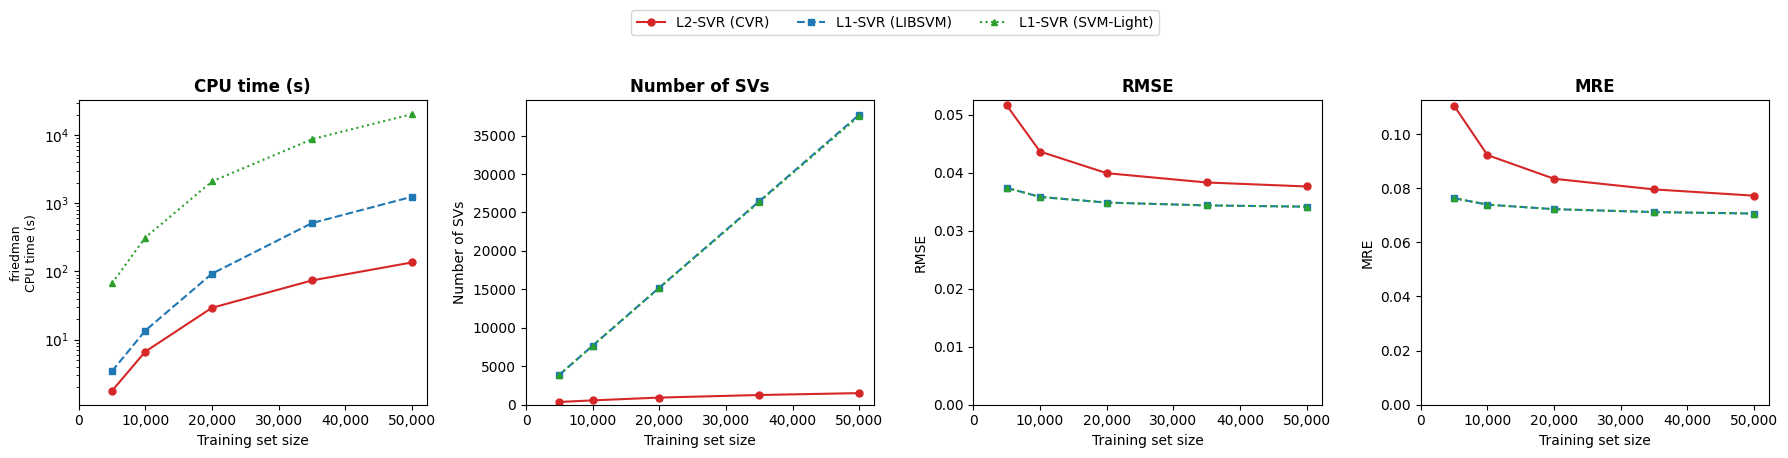

In [29]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

METHOD_STYLE = {
    'L2-SVR (CVR)'        : dict(color='tab:red',   marker='o', linestyle='-',  label='L2-SVR (CVR)'),
    'L1-SVR (LIBSVM)'     : dict(color='tab:blue', marker='s', linestyle='--', label='L1-SVR (LIBSVM)'),
    'L1-SVR (SVM-Light)'  : dict(color='tab:green',  marker='^', linestyle=':',  label='L1-SVR (SVM-Light)'),
    'L2-SVM (CVM-libCVM)' : dict(color='tab:purple',   marker='v', linestyle='-',  label='L2-SVM (CVM-libCVM)'),
    'L2-SVM (CVM)'        : dict(color='tab:cyan', marker='D', linestyle='-.', label='L2-SVM (CVM)'),
    'nu-SVR (LIBSVM)'     : dict(color='tab:orange', marker='s', linestyle='--', label='nu-SVR (LIBSVM)'),
}

# 1. BIỂU ĐỒ REGRESSION
REGRESSION_DATASETS = [ds for ds in results['dataset'].unique() if ds in EXPERIMENT_CONFIG and EXPERIMENT_CONFIG[ds]['task'] == 'regression']
if len(REGRESSION_DATASETS) > 0:
    metrics_reg = [
        ('cpu_time', 'CPU time (s)',  True),
        ('n_sv',     'Number of SVs', False),
        ('rmse',     'RMSE',          False),
        ('mre',      'MRE',           False),
    ]
    fig_reg, axes_reg = plt.subplots(
        nrows=len(REGRESSION_DATASETS), ncols=len(metrics_reg),
        figsize=(18, 4 * len(REGRESSION_DATASETS)), squeeze=False
    )
    for row_i, ds_name in enumerate(REGRESSION_DATASETS):
        df_ds = results[results['dataset'] == ds_name]
        for col_i, (metric, ylabel, use_log) in enumerate(metrics_reg):
            ax = axes_reg[row_i][col_i]
            for method in ['L2-SVR (CVR)', 'L1-SVR (LIBSVM)', 'L1-SVR (SVM-Light)']:
                style = METHOD_STYLE[method]
                df_m = df_ds[df_ds['method'] == method].sort_values('N_train')
                if not df_m.empty:
                    ax.plot(df_m['N_train'], df_m[metric], **style, linewidth=1.5, markersize=5)
            if use_log: ax.set_yscale('log')
            else: ax.set_ylim(bottom=0)
            ax.set_xlim(left=0)
            ax.set_xlabel('Training set size')
            ax.set_ylabel(ylabel)
            ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
            if row_i == 0: ax.set_title(ylabel, fontweight='bold')
            if col_i == 0: ax.set_ylabel(f'{ds_name}\n{ylabel}', fontsize=9)
    handles, labels = axes_reg[0][0].get_legend_handles_labels()
    fig_reg.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.15))
    plt.tight_layout()
    plt.show()

# 2. BIỂU ĐỒ CLASSIFICATION
CLASSIFICATION_DATASETS = [ds for ds in results['dataset'].unique() if ds in EXPERIMENT_CONFIG and EXPERIMENT_CONFIG[ds]['task'] == 'classification']
if len(CLASSIFICATION_DATASETS) > 0:
    metrics_clf = [
        ('cpu_time', 'CPU time (s)',  True),
        ('n_sv',     'Number of SVs', False),
        ('clf_err',  'Classification Error', False),
    ]
    fig_clf, axes_clf = plt.subplots(
        nrows=len(CLASSIFICATION_DATASETS), ncols=len(metrics_clf),
        figsize=(15, 4 * len(CLASSIFICATION_DATASETS)), squeeze=False
    )
    for row_i, ds_name in enumerate(CLASSIFICATION_DATASETS):
        df_ds = results[results['dataset'] == ds_name]
        for col_i, (metric, ylabel, use_log) in enumerate(metrics_clf):
            ax = axes_clf[row_i][col_i]
            for method in ['L2-SVM (CVM-libCVM)', 'L2-SVR (CVR)', 'nu-SVR (LIBSVM)', 'L2-SVM (CVM)']:
                style = METHOD_STYLE[method]
                df_m = df_ds[df_ds['method'] == method].sort_values('N_train')
                if not df_m.empty:
                    ax.plot(df_m['N_train'], df_m[metric], **style, linewidth=1.5, markersize=5)
            if use_log: ax.set_yscale('log')
            else: ax.set_ylim(bottom=0)
            ax.set_xlim(left=0)
            ax.set_xlabel('Training set size')
            ax.set_ylabel(ylabel)
            ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
            if row_i == 0: ax.set_title(ylabel, fontweight='bold')
            if col_i == 0: ax.set_ylabel(f'{ds_name}\n{ylabel}', fontsize=9)

    handles, labels = axes_clf[0][0].get_legend_handles_labels()
    fig_clf.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.15))
    plt.tight_layout()
    plt.show()